In [1]:
#| default_exp periodic

In [2]:
#| hide

import numpy as np
import igl
import matplotlib.pyplot as plt

In [3]:
#| export

import jax
import jax.numpy as jnp

import dataclasses

In [15]:
#| export

from jaxtyping import Float 
from collections.abc import Callable

In [5]:
#| export

from triangulax import trigonometry as trig
from triangulax.triangular import TriMesh
from triangulax.mesh import HeMesh
from triangulax import adjacency as adj

In [6]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [7]:
#| hide

import jaxtyping


In [8]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, %unload_ext jaxtyping 

## Geometric quantities in periodic boundary conditions

In many 2D biophysical simulations (see tutorial 3 on "vertex models"), it is convenient to work with _periodic boundary conditions_, i.e. simulate cells in a box with lengths $\mathbf{L} = [L_x, L_y]$ where opposite sides are identified.
This module contains tools for mesh geometry in periodic boundary conditions.

In `triangulax`, mesh connectivity and geometry are decoupled, so periodic boundary conditions are easy to implement. One need two ingredients:

1. A triangulation whose connectivity has the desired periodicity (e.g. a triangulation of a torus). 

There are different ways to generate a triangulation of the torus - one example is included in `test_meshes/torus_2d.obj`. Note: edge flips/T1 on this mesh will preserve its topology, no further bookkeeping is needed. In particular, one does not need to keep track of any boundary vertices since there is no boundary. All `triangulax` tools related to the mesh connectivity (like the `HeMesh` class) can be used without modification.

2. A distance function that takes into account the periodicity. 

For a square domain with length $L$ the displacement vector between two points $\mathbf{r}_1, \mathbf{r}_2$ can be computed as 
$$\mathbf{d} = \mathbf{r}_1 - \mathbf{r}_2 - \mathrm{round}\left(\frac{|\mathbf{r}_1 - \mathbf{r}_2 |}{L} \right)L$$

This always gives the shortest displacement vector between the two points. With this distance function, one can compute edge lengths, angles, Voronoi duals, etc. Note: nothing prevents you from changing the shape of your domain, i.e. $L$ dynamically during your simulation (for instance, to simulare growing tissues). You can even take gradients with respect to $L$.

In [9]:
#| export

def displacement_periodic(r_1: Float[jax.Array, "2"], r_2: Float[jax.Array, "2"], L: Float[jax.Array, "2"]
                         ) -> Float[jax.Array, "2"]:
    """Return the minimum-image displacement on a rectangular torus.

    Parameters
    ----------
    r_1, r_2
        Positions in a periodic box.
    L
        Box lengths [L_x, L_y].
    """
    d = r_2 - r_1
    return d - L * jnp.round(d / L)


def displacement_periodic_twisted(r_1: Float[jax.Array, "2"], r_2: Float[jax.Array, "2"],
                                  L: Float[jax.Array, "2"], s: float
                                  ) -> Float[jax.Array, "2"]:
    """Return the minimum-image displacement on a sheared periodic torus.

    Parameters
    ----------
    r_1, r_2
        Positions in a periodic box.
    L
        Box lengths [L_x, L_y].
    s
        Shear factor relating vertical wraps to an x-shift of s * L_x.
    """
    d = r_2 - r_1
    twist = s * L[0] * jnp.round(d[1] / L[1])
    d = d.at[0].set(d[0] + twist)
    return d - L * jnp.round(d / L)

In [10]:
L = jnp.array([2.0, 3.0])

assert jnp.allclose(
    displacement_periodic(
        jnp.array([0.1, 0.2]),
        jnp.array([1.9, 2.8]),
        L,
    ),
    jnp.array([-0.2, -0.4]),
)

assert jnp.allclose(
    displacement_periodic(
        jnp.array([1.9, 2.8]),
        jnp.array([0.1, 0.2]),
        L,
    ),
    jnp.array([0.2, 0.4]),
)

assert jnp.allclose(
    displacement_periodic_twisted(
        jnp.array([0.0, 0.0]),
        jnp.array([0.9, 1.1]),
        jnp.array([1.0, 1.0]),
        0.25,
    ),
    jnp.array([0.15, 0.1]),
)

assert jnp.allclose(
    displacement_periodic_twisted(
        jnp.array([0.9, 0.9]),
        jnp.array([0.1, -0.1]),
        jnp.array([1.0, 1.0]),
        0.25,
    ),
    jnp.array([-0.05, 0.0]),
)

### Edge lengths, angles, and areas

Geometric quantities like angles and triangle areas can be computed using the displacement functions defined above.
To do this, we can use the "intrinsic" geometry functions from the trigonometry module to compute everything in terms of edge lengths.



(np.float64(-0.028125350000000004),
 np.float64(1.04895835),
 np.float64(0.03749965),
 np.float64(1.04583335))

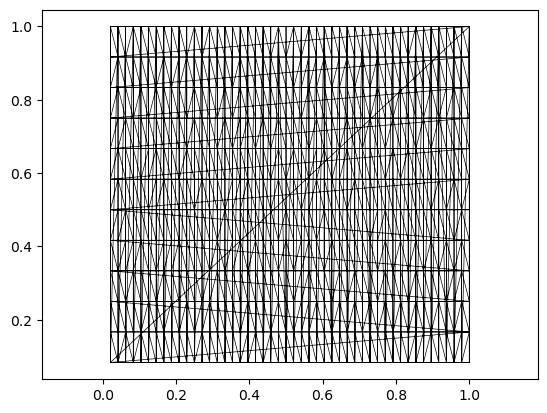

In [11]:
# this is an example of a 2d mesh with "periodic boundary conditions" - topologically, it is just a torus.
# Thus, the faces that wrap around the boundary.

trimesh = TriMesh.read_obj("../test_meshes/torus_2d.obj", dim=2)
hemesh = HeMesh.from_triangles(trimesh.vertices.shape[0], trimesh.faces)

vertices = trimesh.vertices

plt.triplot(vertices[:,0], vertices[:,1], trimesh.faces, lw=0.5, color="k")
plt.axis("equal")

In [12]:
hemesh.bdry_loops  # the mesh has no boundary

[]

In [13]:
# to compute angles, we use the intrinsic geometry of the mesh

L = jnp.array([1.0, 1.0]) # box lengths
def my_distance_function(r_1, r_2): return displacement_periodic(r_1, r_2, L)

edge_lengths = jax.vmap(my_distance_function)(vertices[hemesh.orig], vertices[hemesh.dest])
edge_lengths_nonperiodic = jnp.linalg.norm(vertices[hemesh.orig] - vertices[hemesh.dest], axis=1)

edge_lengths.max(), edge_lengths_nonperiodic.max()

(Array(0.083334, dtype=float64), Array(1.34128535, dtype=float64))

In [14]:
# let's group together the edge lengths for each face, then compute the area

la, lb, lc = (edge_lengths[hemesh.prv[hemesh.face_incident]],
              edge_lengths[hemesh.face_incident],
              edge_lengths[hemesh.nxt[hemesh.face_incident]],)

angles = jax.vmap(trig.get_angles_from_lengths)(la, lb, lc)
areas = jax.vmap(trig.get_triangle_area_from_lengths)(la, lb, lc)

In [16]:
#| export


def _get_periodic_face_edge_lengths(vertices: Float[jax.Array, "n_vertices 2"], hemesh: HeMesh,
                                    distance_function: Callable,
                                    ) -> tuple[Float[jax.Array, " n_faces"],
                                               Float[jax.Array, " n_faces"],
                                               Float[jax.Array, " n_faces"]]:
    """Return face-local edge lengths from a user-specified displacement function."""
    edge_vectors = jax.vmap(distance_function)(vertices[hemesh.orig], vertices[hemesh.dest])
    edge_lengths = jnp.linalg.norm(edge_vectors, axis=-1)
    return (edge_lengths[hemesh.prv[hemesh.face_incident]],
            edge_lengths[hemesh.face_incident],
            edge_lengths[hemesh.nxt[hemesh.face_incident]],)


def get_periodic_triangle_areas(vertices: Float[jax.Array, "n_vertices 2"], hemesh: HeMesh,
                                distance_function: Callable,
                                ) -> Float[jax.Array, " n_faces"]:
    """Compute triangle areas using a periodic distance function."""
    la, lb, lc = _get_periodic_face_edge_lengths(vertices, hemesh, distance_function)
    return jax.vmap(trig.get_triangle_area_from_lengths)(la, lb, lc)


def get_periodicb_arycentric_cell_areas(vertices: Float[jax.Array, "n_vertices 2"], hemesh: HeMesh,
                                distance_function: Callable,
                                ) -> Float[jax.Array, " n_faces"]:
    """Get area of barycentric dual cell around each vertex, using a periodic distance function.
    Defined as 1/3 * sum of adjacent triangle areas."""
    triangle_areas = get_periodic_triangle_areas(vertices, hemesh, distance_function)
    return adj.sum_face_to_vertex(hemesh, triangle_areas) / 3.0


def get_periodic_corner_angles(vertices: Float[jax.Array, "n_vertices 2"], hemesh: HeMesh,
                              distance_function: Callable
                              ) -> Float[jax.Array, " n_faces 3"]:
    """Compute all face corner angles using a periodic distance function."""
    la, lb, lc = _get_periodic_face_edge_lengths(vertices, hemesh, distance_function)
    return jax.vmap(trig.get_angles_from_lengths)(la, lb, lc)


def get_periodic_corner_cotangents(vertices: Float[jax.Array, "n_vertices 2"], hemesh: HeMesh,
                                   distance_function: Callable,
                                   ) -> Float[jax.Array, " n_faces 3"]:
    """Compute all face corner cotangents using a periodic displacement function."""
    la, lb, lc = _get_periodic_face_edge_lengths(vertices, hemesh, distance_function)
    return jax.vmap(trig.get_cotangents_from_lengths)(la, lb, lc)

In [17]:
periodic_distance = lambda r_1, r_2: displacement_periodic(r_1, r_2, L)

periodic_areas = get_periodic_triangle_areas(vertices, hemesh, periodic_distance)
periodic_angles = get_periodic_corner_angles(vertices, hemesh, periodic_distance)
periodic_cotangents = get_periodic_corner_cotangents(vertices, hemesh, periodic_distance)

manual_edge_lengths = jnp.linalg.norm(
    jax.vmap(periodic_distance)(vertices[hemesh.orig], vertices[hemesh.dest]),
    axis=-1,
 )
la_test, lb_test, lc_test = (manual_edge_lengths[hemesh.prv[hemesh.face_incident]],
                             manual_edge_lengths[hemesh.face_incident],
                             manual_edge_lengths[hemesh.nxt[hemesh.face_incident]],)

assert periodic_areas.shape == (hemesh.n_faces,)
assert periodic_angles.shape == (hemesh.n_faces, 3)
assert periodic_cotangents.shape == (hemesh.n_faces, 3)

assert jnp.allclose(
    periodic_areas,
    jax.vmap(trig.get_triangle_area_from_lengths)(la_test, lb_test, lc_test),
)
assert jnp.allclose(
    periodic_angles,
    jax.vmap(trig.get_angles_from_lengths)(la_test, lb_test, lc_test),
)
assert jnp.allclose(
    periodic_cotangents,
    jax.vmap(trig.get_cotangents_from_lengths)(la_test, lb_test, lc_test),
)

zero_twist_distance = lambda r_1, r_2: displacement_periodic_twisted(r_1, r_2, L, 0.0)
assert jnp.allclose(
    periodic_areas,
    get_periodic_triangle_areas(vertices, hemesh, zero_twist_distance),
)
assert jnp.allclose(
    periodic_angles,
    get_periodic_corner_angles(vertices, hemesh, zero_twist_distance),
)
assert jnp.allclose(
    periodic_cotangents,
    get_periodic_corner_cotangents(vertices, hemesh, zero_twist_distance),
)

print("periodic geometry tests passed")

periodic geometry tests passed


### Voronoi dual

We can also compute the Voronoi dual for a periodic boundary conditions. To do so, we use the intrisic "circumcenter" function.

In [19]:
#| export

def _get_periodic_he_lengths(
    vertices: Float[jax.Array, "n_vertices 2"],
    hemesh: HeMesh,
    distance_function: Callable[[Float[jax.Array, "2"], Float[jax.Array, "2"]], Float[jax.Array, "2"]],
) -> Float[jax.Array, "n_hes"]:
    """Return half-edge lengths from a user-specified periodic displacement."""
    edge_vectors = jax.vmap(distance_function)(vertices[hemesh.orig], vertices[hemesh.dest])
    return jnp.linalg.norm(edge_vectors, axis=-1)


def _get_periodic_cotan_weights_per_edge(
    vertices: Float[jax.Array, "n_vertices 2"],
    hemesh: HeMesh,
    distance_function: Callable[[Float[jax.Array, "2"], Float[jax.Array, "2"]], Float[jax.Array, "2"]],
) -> Float[jax.Array, "n_hes"]:
    """Return per-edge cotangent weights from periodic face geometry."""
    face_cotangents = get_periodic_corner_cotangents(vertices, hemesh, distance_function)
    per_he = jnp.zeros(hemesh.n_hes, dtype=vertices.dtype)
    per_he = per_he.at[hemesh.prv[hemesh.face_incident]].set(face_cotangents[:, 0])
    per_he = per_he.at[hemesh.face_incident].set(face_cotangents[:, 1])
    per_he = per_he.at[hemesh.nxt[hemesh.face_incident]].set(face_cotangents[:, 2])
    return (per_he + per_he[hemesh.twin]) / 2


def get_periodic_voronoi_areas(
    vertices: Float[jax.Array, "n_vertices 2"],
    hemesh: HeMesh,
    distance_function: Callable[[Float[jax.Array, "2"], Float[jax.Array, "2"]], Float[jax.Array, "2"]],
) -> Float[jax.Array, "n_vertices"]:
    """Compute Voronoi cell areas from periodic edge lengths and cotangent weights."""
    edge_lengths = _get_periodic_he_lengths(vertices, hemesh, distance_function)
    edge_areas = _get_periodic_cotan_weights_per_edge(vertices, hemesh, distance_function) * edge_lengths**2 / 4
    return adj.sum_he_to_vertex_incoming(hemesh, edge_areas)


def get_periodic_voronoi_face_positions(
    vertices: Float[jax.Array, "n_vertices 2"],
    hemesh: HeMesh,
    distance_function: Callable[[Float[jax.Array, "2"], Float[jax.Array, "2"]], Float[jax.Array, "2"]],
) -> Float[jax.Array, "n_faces 2"]:
    """Compute periodic Voronoi dual positions from intrinsic circumcenter barycentric coordinates."""
    face_hes = hemesh.face_incident
    edge_lengths = _get_periodic_he_lengths(vertices, hemesh, distance_function)
    la = edge_lengths[hemesh.nxt[face_hes]]
    lb = edge_lengths[hemesh.prv[face_hes]]
    lc = edge_lengths[face_hes]
    barycentric = jax.vmap(trig.get_circumcenter_from_lengths)(la, lb, lc)

    a = vertices[hemesh.orig[face_hes]]
    ab = jax.vmap(distance_function)(vertices[hemesh.orig[face_hes]], vertices[hemesh.dest[face_hes]])
    bc = jax.vmap(distance_function)(vertices[hemesh.orig[hemesh.nxt[face_hes]]],
                                     vertices[hemesh.dest[hemesh.nxt[face_hes]]])
    b = a + ab
    c = b + bc
    return (barycentric[:, :1] * a
            + barycentric[:, 1:2] * b
            + barycentric[:, 2:3] * c)

In [20]:
periodic_voronoi_areas = get_periodic_voronoi_areas(vertices, hemesh, periodic_distance)
periodic_face_positions = get_periodic_voronoi_face_positions(vertices, hemesh, periodic_distance)

periodic_he_lengths = _get_periodic_he_lengths(vertices, hemesh, periodic_distance)
periodic_cotan_weights = _get_periodic_cotan_weights_per_edge(vertices, hemesh, periodic_distance)

assert periodic_voronoi_areas.shape == (hemesh.n_vertices,)
assert periodic_face_positions.shape == (hemesh.n_faces, 2)

assert jnp.allclose(
    periodic_voronoi_areas,
    adj.sum_he_to_vertex_incoming(
        hemesh,
        periodic_cotan_weights * periodic_he_lengths**2 / 4,
    ),
)
assert jnp.allclose(periodic_voronoi_areas.sum(), periodic_areas.sum())

face_hes = hemesh.face_incident
a = vertices[hemesh.orig[face_hes]]
ab = jax.vmap(periodic_distance)(vertices[hemesh.orig[face_hes]], vertices[hemesh.dest[face_hes]])
bc = jax.vmap(periodic_distance)(vertices[hemesh.orig[hemesh.nxt[face_hes]]],
                                 vertices[hemesh.dest[hemesh.nxt[face_hes]]])
b = a + ab
c = b + bc
radii_a = jnp.linalg.norm(periodic_face_positions - a, axis=1)
radii_b = jnp.linalg.norm(periodic_face_positions - b, axis=1)
radii_c = jnp.linalg.norm(periodic_face_positions - c, axis=1)
assert jnp.allclose(radii_a, radii_b)
assert jnp.allclose(radii_b, radii_c)

zero_twist_distance = lambda r_1, r_2: displacement_periodic_twisted(r_1, r_2, L, 0.0)
assert jnp.allclose(
    periodic_voronoi_areas,
    get_periodic_voronoi_areas(vertices, hemesh, zero_twist_distance),
)
assert jnp.allclose(
    periodic_face_positions,
    get_periodic_voronoi_face_positions(vertices, hemesh, zero_twist_distance),
)

print("periodic Voronoi tests passed")

periodic Voronoi tests passed
